# QUANTIFI 3팀 — 이익수정(SUR) 롱 / 커버일수 숏 롱숏 전략 (확정 설계 v8)

**팀원** 류지연 · 채종원 · 이재상 · 장서현 · 권태은

이 노트북 하나로 가공 데이터를 불러와 v8 전략을 백테스트하고 성과·회귀·체결률·보유 종목을 산출합니다.
전략 논리와 설계 근거는 `docs/strategy_v8.md`에 있습니다.

| 폴더 | 내용 |
|---|---|
| `data/raw/` | DataGuide 원천 엑셀, KRX 과열종목·지수 구성종목, 네이버 업종 (저장소에는 포함하지 않음, `data/README.md` 참고) |
| `data/processed/` | 원천을 변환한 parquet·csv (`code/build_processed_data.py`로 생성) |
| `code/strategy_v8.py` | 백테스트 엔진 (규칙은 파일 맨 위 `PARAMS`) |
| `output/` | 이 노트북이 저장하는 결과 |

**실행 순서**: 위에서부터 차례로 실행합니다. 원천에서 가공 데이터를 다시 만들려면 2번 셀의 `RUN_BUILD = True`로 바꿉니다 (엑셀 읽기에 수 분).

## 1. 환경 설정
필요 패키지: `numpy pandas pyarrow statsmodels scikit-learn matplotlib openpyxl`

In [1]:
import sys, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent                # 이 노트북은 notebooks 폴더에서 실행
CODE = ROOT / "code"
OUT = ROOT / "output"; OUT.mkdir(exist_ok=True)
sys.path.insert(0, str(CODE))
import strategy_v8 as S

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
KFONT = next((f for f in ["AppleGothic", "Malgun Gothic", "NanumGothic"] if f in _avail), "DejaVu Sans")   # 한글 글꼴 (macOS·Windows·Linux)
plt.rcParams.update({"font.family": KFONT,
                     "axes.unicode_minus": False, "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
def fmt(df, pct=(), dec=(), p=1, d=2):
    # 표시용 서식: pct 열은 %, dec 열은 소수점
    x = df.copy().astype(object)
    for c in x.columns:
        if pct == "all" or c in pct: x[c] = [f"{v:.{p}%}" if isinstance(v, (int, float, np.floating)) and pd.notna(v) else v for v in df[c]]
        elif c in dec: x[c] = [f"{v:.{d}f}" if isinstance(v, (int, float, np.floating)) and pd.notna(v) else v for v in df[c]]
    return x
pd.Series({k: (str(v.date()) if hasattr(v, "date") else v) for k, v in S.PARAMS.items()}, name="규칙").to_frame()

,규칙
START,2016-12-01
END,2026-07-31
DATA_START,2013-01-01
DATA_END,2026-08-31
TOP_CAP,0.3
SUR_WIN,12
SUR_MIN,8
WINSOR,0.01
LPCT,0.1
SPCT,0.1


## 2. (선택) 원천 → 가공 데이터 재생성
`data/processed`에 변환된 파일이 있어야 합니다. 원천(`data/raw`)에서 만들 때만 실행합니다.

In [2]:
RUN_BUILD = False
if RUN_BUILD:
    subprocess.run([sys.executable, str(CODE / "build_processed_data.py")], check=True)
sorted(p.name for p in (ROOT / "data" / "processed").iterdir())

['cd91.parquet',
 'eps_rev_fy1.parquet',
 'eps_rev_fy2.parquet',
 'ff3.parquet',
 'fn_ig27_monthly.parquet',
 'index_px.parquet',
 'industry_fill.csv',
 'k200_member_monthly.parquet',
 'kospi200_kosdaq150_membership.csv',
 'mktcap.parquet',
 'naver_to_ig27_map.csv',
 'overheat.parquet',
 'px_close_tr.parquet',
 'short_bal.parquet',
 'stock_names.csv',
 'tradeval.parquet']

## 3. 데이터 불러오기
신호일은 매월 마지막 거래일, 보유수익률은 **신호 다음 거래일 종가 → 다음 신호 다음 거래일 종가**(현금배당 포함 수정종가, 총수익)입니다.

In [3]:
D = S.load_data()
dates = D["dates"]; bt = dates[(dates >= S.PARAMS["START"]) & (dates <= S.PARAMS["END"])]
pd.DataFrame({
    "신호일 수": [len(bt)], "첫 신호일": [bt[0].date()], "마지막 신호일": [bt[-1].date()],
    "전체 종목 수": [len(D["cols"])],
    "월평균 유니버스(보통주 시총 상위30%)": [D["top"].loc[bt].sum(axis=1).mean()],
    "월평균 롱 후보(SUR 있음)": [D["sur"].loc[bt].where(D["top"].loc[bt]).notna().sum(axis=1).mean()],
    "공매도 금지 신호월": [int(D["ban"].loc[bt].sum())],
}).T.rename(columns={0: "값"})

,값
신호일 수,116
첫 신호일,2016-12-29
마지막 신호일,2026-07-31
전체 종목 수,3987
월평균 유니버스(보통주 시총 상위30%),684.793103
월평균 롱 후보(SUR 있음),367.051724
공매도 금지 신호월,30


## 4. 신호
- **SUR** = EPS 1개월 변화율(1~10월 FY1, 11~12월 FY2)을 횡단면 1/99% 윈저라이징 → 자기 과거 12개월 표준편차(최소 8개월)로 나눔. "평소 변동 대비 얼마나 큰 상향인가"를 잰다.
- **커버일수** = 차입공매도잔고비율(T+2 공시 → 3거래일 지연) ÷ 21일 평균 거래회전율. 공매도 잔고를 청산하는 데 며칠이 걸리는지 = 공매도 투자자의 확신.

마지막 신호월의 상위 종목입니다.

In [4]:
t = bt[-1]
sur_top = D["sur"].loc[t].where(D["top"].loc[t]).dropna().sort_values(ascending=False).head(10)
dtc_ok = D["mem"].loc[t].eq("KOSPI200") & ~D["overheat"].loc[t]
dtc_top = D["dtc"].loc[t].where(dtc_ok).dropna().sort_values(ascending=False).head(10)
a = pd.DataFrame({"종목": [D["NAME"].get(c, c) for c in sur_top.index], "EPS 변화율%": D["raw"].loc[t, sur_top.index].values,
                  "12M 표준편차": D["sd"].loc[t, sur_top.index].values, "SUR": sur_top.values}, index=sur_top.index)
b = pd.DataFrame({"종목": [D["NAME"].get(c, c) for c in dtc_top.index], "잔고비율%": D["si_ratio"].loc[t, dtc_top.index].values,
                  "커버일수 백분위": dtc_top.values, "업종": D["ind"].loc[t, dtc_top.index].values}, index=dtc_top.index)
print(f"신호일 {t:%Y-%m-%d} — SUR 상위 10"); display(a.round(2))
print("커버일수 상위 10 (KOSPI200, 과열종목 제외)"); display(b.round(3))

신호일 2026-07-31 — SUR 상위 10


,종목,EPS 변화율%,12M 표준편차,SUR
039490,키움증권,13.28,4.09,3.25
028050,삼성E&A,4.95,1.55,3.19
042660,한화오션,25.24,8.22,3.07
000810,삼성화재,4.27,1.40,3.05
055550,신한지주,5.51,1.88,2.93
128940,한미약품,12.53,4.32,2.90
007690,국도화학,37.83,13.27,2.85
009540,HD한국조선해양,9.99,3.51,2.85
011200,HMM,25.33,9.37,2.70
016380,KG스틸,20.59,8.08,2.55


커버일수 상위 10 (KOSPI200, 과열종목 제외)


,종목,잔고비율%,커버일수 백분위,업종
026960,동서,1.72,1.000,음식료및담배
000080,하이트진로,2.83,1.000,음식료및담배
137310,에스디바이오센서,1.31,0.999,의료
302440,SK바이오사이언스,1.45,0.996,의료
361610,SK아이이테크놀로지,2.66,0.996,하드웨어
0126Z0,삼성에피스홀딩스,2.49,0.994,의료
009240,한샘,2.04,0.994,내구소비재및의류
373220,LG에너지솔루션,1.53,0.994,하드웨어
007310,오뚜기,1.40,0.993,음식료및담배
300720,한일시멘트,1.50,0.993,기타 소재


### 4-2. 신호 검증 — 5분위와 시가총액 교차 히트맵
비중·비용과 무관하게 **신호 자체**가 다음 보유기간 수익률을 가르는지 봅니다 (동일가중, 매달 다시 분류).
- SUR: 롱 유니버스(보통주 시총 상위 30%) 116개월. 비교로 표준화하지 않은 원 리비전도 함께.
- 커버일수: 숏 유니버스(KOSPI200, 과열종목 제외), 공매도 금지가 아닌 86개월. **높을수록 이후 수익률이 낮아야** 숏 신호입니다.

CAGR  산술 연율      t     개월
SUR   Q1      4.8%   7.1%   1.10  116.0
      Q2      7.7%   9.7%   1.53  116.0
      Q3      9.9%  12.0%   1.82  116.0
      Q4     13.0%  14.6%   2.24  116.0
      Q5     19.0%  19.8%   2.75  116.0
      Q5-Q1  12.8%  12.6%   4.58  116.0
원 리비전 Q1      6.2%   8.7%   1.35  116.0
      Q2      6.9%   8.9%   1.42  116.0
      Q3      8.2%  10.6%   1.53  116.0
      Q4     11.2%  13.2%   1.98  116.0
      Q5     16.6%  18.0%   2.37  116.0
      Q5-Q1   9.2%   9.3%   3.07  116.0
커버일수  Q1      3.5%   6.2%   0.67   86.0
      Q2      3.2%   6.0%   0.67   86.0
      Q3      1.7%   4.0%   0.46   86.0
      Q4     -1.7%   0.5%   0.06   86.0
      Q5     -1.8%   0.5%   0.06   86.0
      Q5-Q1  -6.3%  -5.7%  -1.22   86.0

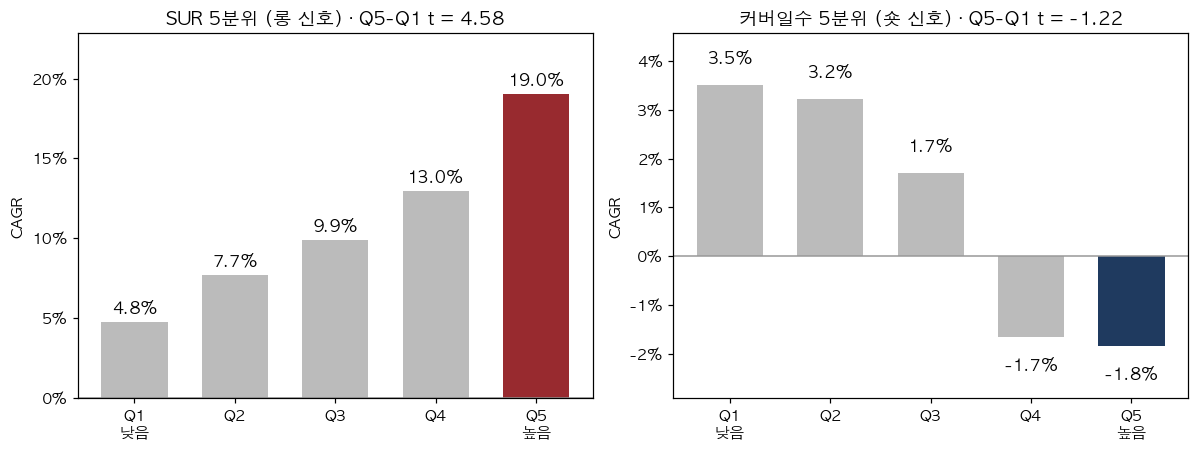

In [5]:
long_u = lambda t: D["top"].loc[t].fillna(False)
short_u = lambda t: D["mem"].loc[t].eq("KOSPI200") & ~D["overheat"].loc[t]
nb_months = [t for t in bt if not D["ban"].loc[t]]
Q_SUR = S.quintile_test(D, D["sur"], bt)
Q_RAW = S.quintile_test(D, D["raw"].where(D["tradable"]), bt)
Q_DTC = S.quintile_test(D, D["dtc"], nb_months, short_u)
QT = pd.concat({"SUR": Q_SUR, "원 리비전": Q_RAW, "커버일수": Q_DTC}); QT.to_csv(OUT / "quintiles.csv", encoding="utf-8-sig")
display(fmt(QT, pct=["CAGR", "산술 연율"], dec=["t"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a_, (Q, lab, col) in zip(ax, [(Q_SUR, "SUR 5분위 (롱 신호)", "#982A2F"), (Q_DTC, "커버일수 5분위 (숏 신호)", "#1F3A5F")]):
    v = Q.loc[["Q1", "Q2", "Q3", "Q4", "Q5"], "CAGR"].values
    a_.bar(range(5), v, color=["#BBBBBB"] * 4 + [col], width=0.66); a_.axhline(0, color="#999999", lw=1)
    for i, x in enumerate(v): a_.text(i, x + (0.004 if x >= 0 else -0.004), f"{x:.1%}", ha="center", va="bottom" if x >= 0 else "top", fontsize=11)
    a_.set_xticks(range(5)); a_.set_xticklabels(["Q1\n낮음", "Q2", "Q3", "Q4", "Q5\n높음"]); a_.set_ylabel("CAGR")
    a_.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")); a_.margins(y=0.2)
    a_.set_title(f"{lab} · Q5-Q1 t = {Q.loc['Q5-Q1', 't']:.2f}")
plt.tight_layout(); fig.savefig(OUT / "fig_quintiles.png", dpi=160); plt.show()

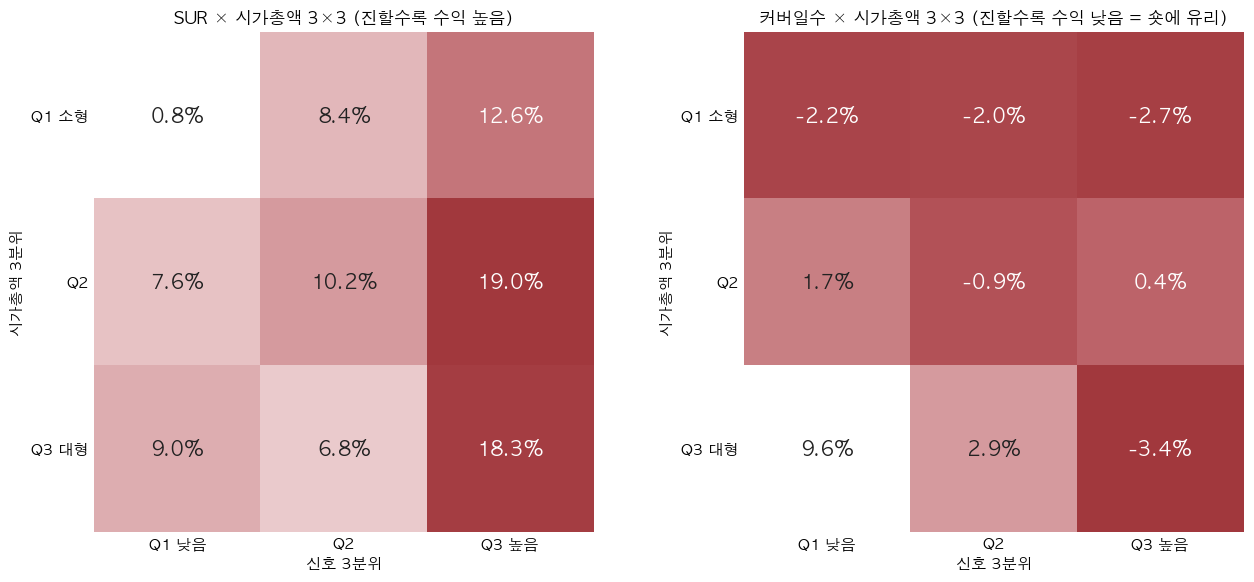

[3×3] SUR: 시총 구간별 최상위 - 최하위 ['+11.8%p', '+11.4%p', '+9.3%p'] | 커버일수: ['-0.5%p', '-1.3%p', '-13.0%p']


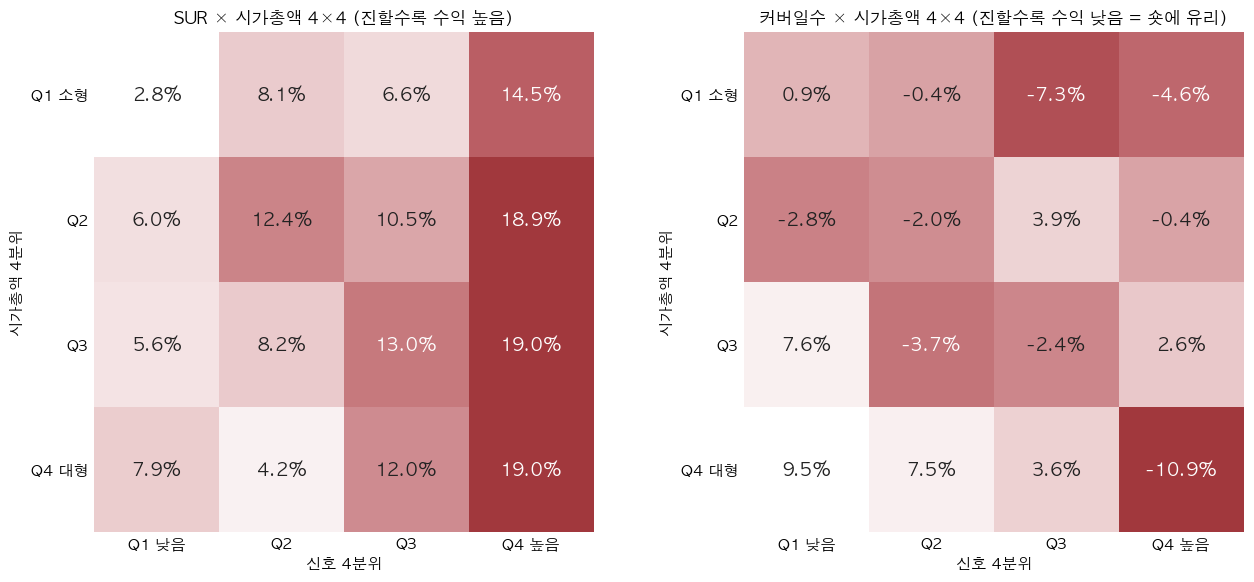

[4×4] SUR: 시총 구간별 최상위 - 최하위 ['+11.7%p', '+12.9%p', '+13.4%p', '+11.1%p'] | 커버일수: ['-5.6%p', '+2.4%p', '-5.0%p', '-20.4%p']


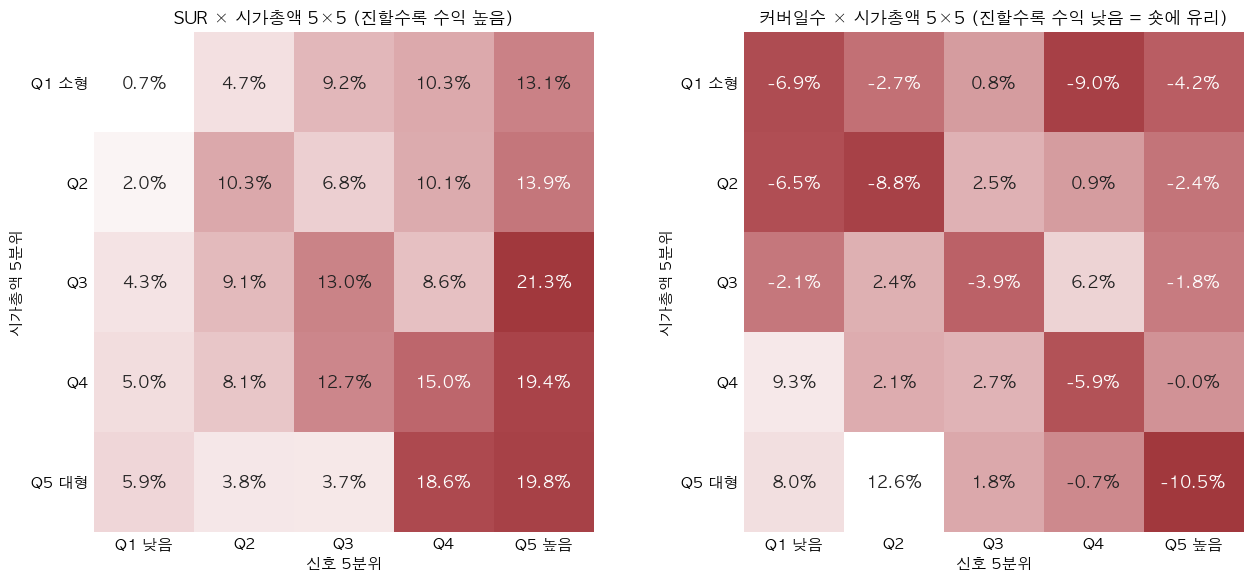

[5×5] SUR: 시총 구간별 최상위 - 최하위 ['+12.4%p', '+11.9%p', '+17.0%p', '+14.4%p', '+13.8%p'] | 커버일수: ['+2.8%p', '+4.1%p', '+0.3%p', '-9.3%p', '-18.4%p']


In [6]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("b", ["#FFFFFF", "#E8C4C6", "#B85A60", "#982A2F"])
HEAT = {}
for q in (3, 4, 5):
    H_SUR = S.size_grid(D, D["sur"], bt, long_u, q); H_DTC = S.size_grid(D, D["dtc"], nb_months, short_u, q); HEAT[q] = (H_SUR, H_DTC)
    H_SUR.to_csv(OUT / f"heatmap_sur_x_size_{q}x{q}.csv", encoding="utf-8-sig"); H_DTC.to_csv(OUT / f"heatmap_dtc_x_size_{q}x{q}.csv", encoding="utf-8-sig")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5.4))
    for a_, (H, lab, inv) in zip(ax, [(H_SUR, f"SUR × 시가총액 {q}×{q} (진할수록 수익 높음)", False), (H_DTC, f"커버일수 × 시가총액 {q}×{q} (진할수록 수익 낮음 = 숏에 유리)", True)]):
        V = H.values; N = (V - V.min()) / (V.max() - V.min()); N = 1 - N if inv else N
        a_.imshow(N * 0.9, cmap=cmap, vmin=0, vmax=1, aspect="equal")
        for i in range(q):
            for j in range(q): a_.text(j, i, f"{V[i, j]:.1%}", ha="center", va="center", fontsize=11 + (5 - q), color="white" if N[i, j] * 0.9 > 0.55 else "#222222")
        xt = [f"Q{j + 1}" for j in range(q)]; xt[0] += " 낮음"; xt[-1] += " 높음"; yt = [f"Q{i + 1}" for i in range(q)]; yt[0] += " 소형"; yt[-1] += " 대형"
        a_.set_xticks(range(q)); a_.set_xticklabels(xt); a_.set_yticks(range(q)); a_.set_yticklabels(yt)
        a_.set_xlabel(f"신호 {q}분위"); a_.set_ylabel(f"시가총액 {q}분위"); a_.set_title(lab, fontsize=11); a_.tick_params(length=0)
        for sp in a_.spines.values(): sp.set_visible(False)
    plt.tight_layout(); fig.savefig(OUT / f"fig_heatmaps_{q}x{q}.png", dpi=160); plt.show()
    print(f"[{q}×{q}] SUR: 시총 구간별 최상위 - 최하위", [f"{(H_SUR.iloc[i, -1] - H_SUR.iloc[i, 0]) * 100:+.1f}%p" for i in range(q)],
          "| 커버일수:", [f"{(H_DTC.iloc[i, -1] - H_DTC.iloc[i, 0]) * 100:+.1f}%p" for i in range(q)])

## 5. 백테스트 실행
롱 100% / 숏 100%(gross 200%), 공매도 금지기간은 롱 100%만. 비중은 최소분산과 √거래대금의 혼합(롱 0.65 · 숏 0.70), 업종 30% 상한, 숏 +30% 손절.

**포지션 회계**
- 회전율(거래비용) = |새 목표 비중 − 직전 보유가 한 달 수익률로 떠내려간 비중|. 목표끼리 비교하지 않는다.
- 손절된 숏은 청산 매수 1회로 비용을 세고, 다음 리밸런싱은 보유 0에서 출발한다.
- 손절 종목의 대차비용과 숏 매도대금 이자(CD91)는 실제 보유 거래일 비율만큼만 반영한다 (`S_hold` = 보유일수 가중 숏 노출).

In [7]:
M, H, EV, SHRINK = S.run_backtest(D)
tot = M.ex + M.rf                                   # 전략 총수익 (비용·리베이트 반영)
pre = M.ex + M.tc + M.bc + M.rf                     # 비용 차감 전
K = M.mkt                                           # KOSPI200 같은 보유기간
M.to_csv(OUT / "monthly.csv", encoding="utf-8-sig")
M[["ex", "L", "S", "S_hold", "long", "short", "to", "tc", "bc", "rebate", "rf", "mkt", "n_long", "n_short", "n_stop"]].tail()

,ex,L,S,S_hold,long,short,to,tc,bc,rebate,rf,mkt,n_long,n_short,n_stop
date,,,,,,,,,,,,,,,
2026-03-31,0.217091,1.0,1.0,0.973659,0.309497,0.086070,1.535931,0.003840,0.002434,0.002288,0.002350,0.289762,38,18,2
2026-04-30,0.184421,1.0,1.0,1.000000,0.106131,-0.084279,1.395786,0.003489,0.002500,0.002342,0.002342,0.333679,38,18,0
2026-05-29,0.121855,1.0,1.0,1.000000,0.019540,-0.109943,2.051300,0.005128,0.002500,0.002383,0.002383,-0.046110,39,18,0
2026-06-30,-0.151202,1.0,1.0,1.000000,-0.190309,-0.046194,1.834864,0.004587,0.002500,0.002433,0.002433,-0.261083,40,18,0
2026-07-31,0.016012,1.0,1.0,0.989950,0.100729,0.077481,1.894381,0.004736,0.002475,0.002434,0.002458,0.089772,40,17,2


## 6. 성과 요약 (총수익 기준, Sharpe는 CD91 차감)

In [8]:
P = pd.DataFrame({"전략 (비용 후)": S.perf(tot, M.rf), "전략 (비용 전)": S.perf(pre, M.rf), "KOSPI200": S.perf(K, M.rf),
                  "참고: 리베이트 없음": S.perf(tot - M.rebate, M.rf)}).T
P.to_csv(OUT / "performance.csv", encoding="utf-8-sig")
fmt(P, pct=["누적", "CAGR", "연변동성", "MDD", "최악의달", "최고의달", "월승률(>0)"], dec=["Sharpe(CD91차감)", "Sortino", "Calmar"])

,누적,CAGR,연변동성,Sharpe(CD91차감),Sortino,MDD,MDD구간(신호월),최악의달,최고의달,월승률(>0),Calmar,개월
전략 (비용 후),896.7%,26.9%,18.7%,1.26,2.76,-18.9%,2021-12→2023-10,-14.9%,21.9%,63.8%,1.42,116
전략 (비용 전),1907.5%,36.4%,18.6%,1.66,4.07,-14.2%,2026-05→2026-06,-14.2%,22.6%,69.0%,2.57,116
KOSPI200,313.0%,15.8%,27.5%,0.59,1.07,-33.9%,2021-05→2022-08,-26.1%,33.4%,58.6%,0.47,116
참고: 리베이트 없음,758.1%,24.9%,18.7%,1.17,2.51,-23.3%,2021-12→2023-10,-15.1%,21.7%,62.9%,1.07,116


## 7. 연도별 수익률 (보유 연도 기준)

In [9]:
cal = D["cal"]
entry = pd.DatetimeIndex([cal[cal.searchsorted(t, side="right")] for t in M.index])
Y = pd.DataFrame({"전략 (비용 후)": tot.values, "전략 (비용 전)": pre.values, "KOSPI200": K.values}, index=entry)
Y = Y.groupby(Y.index.year).apply(lambda g: (1 + g).prod() - 1)
Y.to_csv(OUT / "yearly.csv", encoding="utf-8-sig")
fmt(Y, pct="all")

,전략 (비용 후),전략 (비용 전),KOSPI200
2017,8.6%,18.2%,25.2%
2018,14.1%,23.5%,-20.8%
2019,8.9%,17.9%,12.4%
2020,88.7%,98.7%,37.7%
2021,34.6%,43.9%,-1.1%
2022,-5.9%,2.4%,-26.7%
2023,-0.3%,9.0%,24.4%
2024,11.5%,16.3%,-11.9%
2025,59.5%,71.5%,96.4%
2026,74.3%,83.2%,72.3%


## 8. 누적 수익과 낙폭

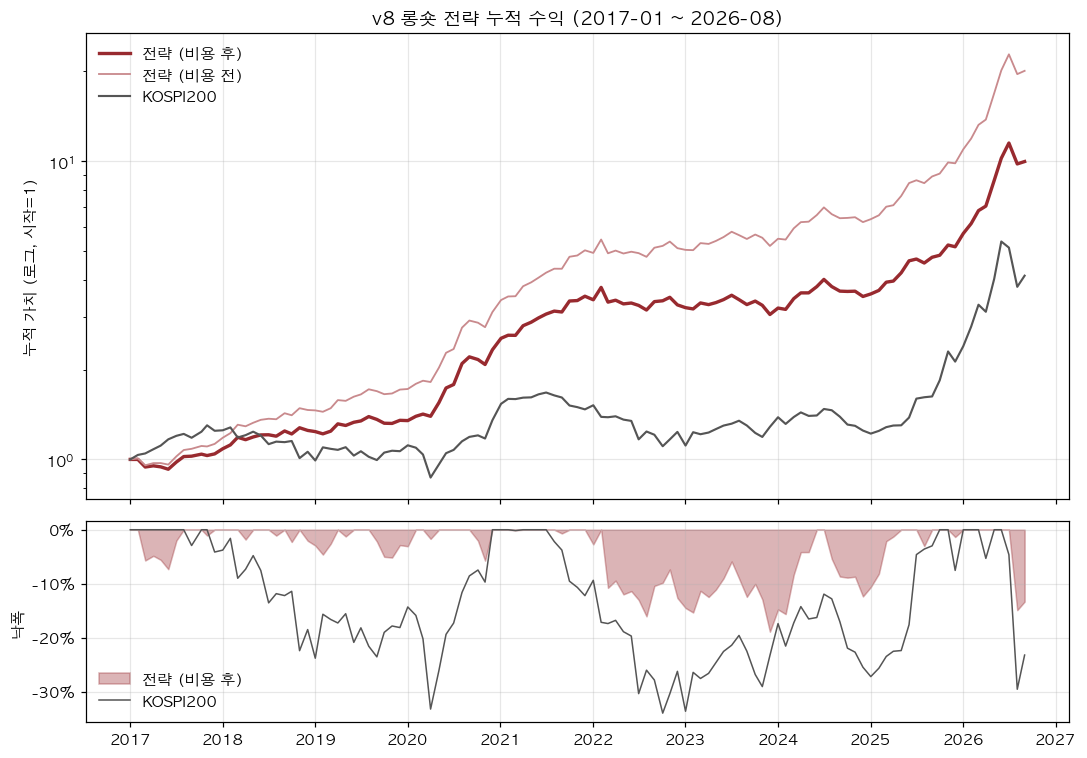

In [10]:
exit_ = pd.DatetimeIndex(list(entry[1:]) + [cal[cal.searchsorted(M.index[-1] + pd.offsets.MonthEnd(1), side="right")]])
nav = pd.DataFrame({"전략 (비용 후)": (1 + tot).cumprod().values, "전략 (비용 전)": (1 + pre).cumprod().values,
                    "KOSPI200": (1 + K).cumprod().values}, index=exit_)
nav = pd.concat([pd.DataFrame(1.0, index=[entry[0]], columns=nav.columns), nav])
nav.to_csv(OUT / "nav.csv", encoding="utf-8-sig")
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1.3]})
for c, col, lw in (("전략 (비용 후)", "#982A2F", 2.2), ("전략 (비용 전)", "#C98A8D", 1.2), ("KOSPI200", "#555555", 1.4)):
    ax[0].plot(nav.index, nav[c], color=col, lw=lw, label=c)
ax[0].set_yscale("log"); ax[0].set_ylabel("누적 가치 (로그, 시작=1)"); ax[0].legend(frameon=False); ax[0].grid(alpha=.3)
ax[0].set_title("v8 롱숏 전략 누적 수익 (2017-01 ~ 2026-08)")
dd = nav / nav.cummax() - 1
ax[1].fill_between(dd.index, dd["전략 (비용 후)"], 0, color="#982A2F", alpha=.35, label="전략 (비용 후)")
ax[1].plot(dd.index, dd["KOSPI200"], color="#555555", lw=1, label="KOSPI200")
ax[1].set_ylabel("낙폭"); ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}")); ax[1].grid(alpha=.3); ax[1].legend(frameon=False, loc="lower left")
plt.tight_layout(); fig.savefig(OUT / "fig_nav_drawdown.png", dpi=160); plt.show()

## 9. 구간별 Sharpe
표본을 3개 구간으로 나눠 특정 시기에만 성과가 몰렸는지 확인합니다 (신호월 기준).

In [11]:
SEG = {"S1 2016-12~2020-01": ("2016-12-01", "2020-01-31"), "S2 2020-02~2023-04": ("2020-02-01", "2023-04-30"),
       "S3 2023-05~2026-07": ("2023-05-01", "2026-07-31")}
seg = pd.DataFrame({k: S.perf(tot.loc[a:b], M.rf.loc[a:b]) for k, (a, b) in SEG.items()}).T[["CAGR", "연변동성", "Sharpe(CD91차감)", "MDD", "개월"]]
fmt(seg, pct=["CAGR", "연변동성", "MDD"], dec=["Sharpe(CD91차감)"])

,CAGR,연변동성,Sharpe(CD91차감),MDD,개월
S1 2016-12~2020-01,11.7%,9.5%,1.05,-7.3%,38
S2 2020-02~2023-04,31.2%,19.4%,1.42,-16.0%,39
S3 2023-05~2026-07,38.8%,23.8%,1.37,-14.9%,39


## 10. 팩터 회귀 (알파·베타)
종속변수는 전략 초과수익(전략 − CD91), HAC 표준오차(3개월 시차). 시장은 두 가지로 봅니다.
- KOSPI200 가격지수
- 코스피+코스닥 전 종목 시가총액가중 총수익 (전략과 같은 보유기간)

In [12]:
mk_all = S.market_all_cw_tr(D).reindex(M.index)
smb, hml = D["smb"].reindex(M.index), D["hml"].reindex(M.index)
rows = []
for mlab, mk in (("KOSPI200", K), ("코스피+코스닥 시총가중", mk_all)):
    for model, X in (("CAPM", pd.DataFrame({"MKT": mk - M.rf})), ("FF3", pd.DataFrame({"MKT": mk - M.rf, "SMB": smb, "HML": hml}))):
        for clab, y in (("비용 후", tot - M.rf), ("비용 전", pre - M.rf)):
            f, n = S.factor_regression(y, X)
            rows.append({"모형": model, "시장": mlab, "비용": clab, "알파(연%)": f.params["const"] * 1200, "알파 t": f.tvalues["const"],
                         "MKT": f.params["MKT"], "MKT t": f.tvalues["MKT"], "SMB": f.params.get("SMB", np.nan), "HML": f.params.get("HML", np.nan),
                         "조정R2": f.rsquared_adj, "n": n})
REG = pd.DataFrame(rows); REG.to_csv(OUT / "factor_regression.csv", encoding="utf-8-sig", index=False)
REG.round(3)

,모형,시장,비용,알파(연%),알파 t,MKT,MKT t,SMB,HML,조정R2,n
0,CAPM,KOSPI200,비용 후,17.898,3.804,0.347,4.255,NaN,NaN,0.254,116
1,CAPM,KOSPI200,비용 전,25.321,5.458,0.345,4.223,NaN,NaN,0.252,116
2,FF3,KOSPI200,비용 후,16.808,3.214,0.345,4.125,-0.046,0.125,0.256,115
3,FF3,KOSPI200,비용 전,24.219,4.712,0.341,4.093,-0.052,0.122,0.254,115
4,CAPM,코스피+코스닥 시총가중,비용 후,18.437,3.901,0.364,3.582,NaN,NaN,0.222,116
5,CAPM,코스피+코스닥 시총가중,비용 전,25.864,5.532,0.361,3.550,NaN,NaN,0.220,116
6,FF3,코스피+코스닥 시총가중,비용 후,16.396,3.134,0.361,3.788,-0.122,0.161,0.243,115
7,FF3,코스피+코스닥 시총가중,비용 전,23.815,4.624,0.356,3.755,-0.127,0.157,0.241,115


## 11. 비용·회전율·노출·손절

In [13]:
a_ = M[M.S > 0]
lw = pd.Series([H[t][0] for t in M.index], index=M.index); sw = pd.Series([H[t][1] for t in a_.index], index=a_.index)
COST = pd.Series({
    "연 회전율(편도 합, 배)": M.to.mean() * 12, "연 거래비용": M.tc.mean() * 12, "연 대차비용": M.bc.mean() * 12,
    "연 숏 리베이트(CD91)": M.rebate.mean() * 12, "숏 운용 월": int((M.S > 0).sum()), "공매도 금지 월": int((M.S == 0).sum()),
    "롱 종목 수 평균": M.n_long.mean(), "숏 종목 수 평균(숏월)": a_.n_short.mean(),
    "롱 최대 비중 평균": np.mean([w.max() for w in lw]), "숏 최대 비중 평균": np.mean([w.max() / w.sum() for w in sw]),
    "롱 유효종목 수 평균(1/Σw²)": np.mean([1 / (w ** 2).sum() for w in lw]),
    "숏 유효종목 수 평균(1/Σw²)": np.mean([1 / ((w / w.sum()) ** 2).sum() for w in sw]),
    "Ledoit-Wolf 수축강도 평균": np.mean(SHRINK),
    "손절 총건수": int(M.n_stop.sum()), "손절 건수/년": M.n_stop.sum() / len(M) * 12,
})
COST.to_csv(OUT / "costs.csv", encoding="utf-8-sig"); display(COST.round(4).to_frame("값"))
if len(EV):
    EV["손절 효과(NAV)"] = -(EV.r_exit - EV.month_end_ret) * EV.w_nav     # + 면 손절이 손실을 줄인 것 (월말까지 들고 있었을 때 대비)
    EV.to_csv(OUT / "stop_events.csv", encoding="utf-8-sig", index=False)
    print(f"손절 {len(EV)}건: 손절이 아꼈던 손실 합 {EV['손절 효과(NAV)'].clip(lower=0).sum():.1%} of NAV, "
          f"손절 뒤 되돌아와 놓친 이익 합 {-EV['손절 효과(NAV)'].clip(upper=0).sum():.1%} of NAV")
    display(EV[["date", "exit_day", "name", "w_nav", "r_exit", "month_end_ret", "손절 효과(NAV)"]].tail(8).round(3))

,값
"연 회전율(편도 합, 배)",20.7469
연 거래비용,0.0519
연 대차비용,0.0220
연 숏 리베이트(CD91),0.0157
숏 운용 월,86.0000
공매도 금지 월,30.0000
롱 종목 수 평균,36.7069
숏 종목 수 평균(숏월),17.9302
롱 최대 비중 평균,0.1096
숏 최대 비중 평균,0.1382


손절 38건: 손절이 아꼈던 손실 합 14.9% of NAV, 손절 뒤 되돌아와 놓친 이익 합 6.0% of NAV


,date,exit_day,name,w_nav,r_exit,month_end_ret,손절 효과(NAV)
30,2025-12-30,2026-01-26,카카오페이,0.049,0.396,0.248,-0.007
31,2025-12-30,2026-01-29,포스코퓨처엠,0.092,0.328,0.263,-0.006
32,2026-01-30,2026-02-20,한진칼,0.030,0.341,0.413,0.002
33,2026-01-30,2026-02-05,한화솔루션,0.065,0.374,1.000,0.041
34,2026-03-31,2026-04-17,SKC,0.045,0.228,0.275,0.002
35,2026-03-31,2026-04-27,호텔신라,0.032,0.491,0.482,-0.000
36,2026-07-31,2026-08-28,포스코퓨처엠,0.076,0.362,0.466,0.008
37,2026-07-31,2026-08-27,SK아이이테크놀로지,0.017,0.362,0.210,-0.003


## 12. 운용 규모별 체결률
하루 거래대금(21일 평균)의 10%까지만 매매한다고 할 때, 3일·5일 안에 체결되는 주문 금액 비율입니다 (116개월 금액 가중, 롱·숏 각 다리 규모).
v8의 거래대금 혼합 비율은 **1,000억 · 5일에서 롱·숏 모두 80% 이상**이 되는 가장 작은 값으로 정했습니다.

In [14]:
FILL = pd.DataFrame([{"규모(억원, 다리별)": aum, "일수": days, **S.fill_rate(D, M, H, aum * 1e8, days)}
                     for aum in (100, 300, 500, 1000, 1500) for days in (3, 5)])
FILL.to_csv(OUT / "fill_rate.csv", encoding="utf-8-sig", index=False)
fmt(FILL.pivot(index="규모(억원, 다리별)", columns="일수", values=["전체", "롱", "숏"]), pct="all")

전체             롱             숏       
일수               3      5      3      5      3      5
규모(억원, 다리별)                                          
100          94.6%  96.6%  94.0%  96.1%  96.9%  98.4%
300          87.7%  91.3%  87.4%  90.8%  88.9%  93.5%
500          83.1%  87.7%  83.1%  87.4%  82.8%  88.9%
1000         74.1%  81.0%  74.9%  81.2%  71.1%  80.2%
1500         67.3%  75.7%  68.6%  76.3%  62.5%  73.2%

### 12-2. 비교: 체결률을 고려하지 않은 비중 (v7 = 최소분산만)
혼합 비율을 0으로 두면(√거래대금 없이 최소분산만) 종목 선정·노출·업종 상한·손절은 같고 비중만 달라집니다.
Sharpe는 더 높지만 소형·저유동 종목에 비중이 몰려 1,000억에서는 주문의 절반 정도만 체결됩니다.

In [15]:
P7 = {**S.PARAMS, "BLEND_L": 0.0, "BLEND_S": 0.0}
M7, H7, _, _ = S.run_backtest(D, P7)
tot7 = M7.ex + M7.rf
CMP = pd.DataFrame({"v8 (체결률 고려)": S.perf(tot, M.rf), "v7 (최소분산만)": S.perf(tot7, M7.rf)}).T[["CAGR", "연변동성", "Sharpe(CD91차감)", "MDD"]]
for lab, (mm, hh) in {"v8 (체결률 고려)": (M, H), "v7 (최소분산만)": (M7, H7)}.items():
    f = S.fill_rate(D, mm, hh, 1000e8, 5); CMP.loc[lab, "1,000억·5일 체결률 롱"] = f["롱"]; CMP.loc[lab, "1,000억·5일 체결률 숏"] = f["숏"]
cap7 = pd.Series({aum: S.fill_rate(D, M7, H7, aum * 1e8, 5)["전체"] for aum in (50, 75, 100, 125, 150, 200)})
CMP.to_csv(OUT / "v8_vs_v7.csv", encoding="utf-8-sig")
display(fmt(CMP, pct=["CAGR", "연변동성", "MDD", "1,000억·5일 체결률 롱", "1,000억·5일 체결률 숏"], dec=["Sharpe(CD91차감)"]))
print("v7 운용 규모별 체결률 (5일, 전체):", {f"{k}억": f"{v:.1%}" for k, v in cap7.items()})
print("→ v7은 체결률 80%를 유지하려면 다리별 약", max(k for k, v in cap7.items() if v >= 0.8), "억원까지가 한계")

,CAGR,연변동성,Sharpe(CD91차감),MDD,"1,000억·5일 체결률 롱","1,000억·5일 체결률 숏"
v8 (체결률 고려),26.9%,18.7%,1.26,-18.9%,81.2%,80.2%
v7 (최소분산만),23.6%,13.6%,1.48,-11.0%,49.4%,54.7%


v7 운용 규모별 체결률 (5일, 전체): {'50억': '91.3%', '75억': '87.7%', '100억': '84.6%', '125억': '81.9%', '150억': '79.8%', '200억': '76.1%'}
→ v7은 체결률 80%를 유지하려면 다리별 약 125 억원까지가 한계


## 13. 최근 보유 종목 (마지막 신호일)

In [16]:
t = M.index[-1]; WL, WS = H[t]
Ls = pd.DataFrame({"종목": [D["NAME"].get(c, c) for c in WL.index], "업종": D["ind"].loc[t].reindex(WL.index).values,
                   "SUR": D["sur"].loc[t].reindex(WL.index).values, "비중": WL.values}, index=WL.index).sort_values("비중", ascending=False)
Ss = pd.DataFrame({"종목": [D["NAME"].get(c, c) for c in WS.index], "업종": D["ind"].loc[t].reindex(WS.index).values,
                   "커버일수 백분위": D["dtc"].loc[t].reindex(WS.index).values, "비중": WS.values}, index=WS.index).sort_values("비중", ascending=False)
Ls.to_csv(OUT / "holdings_long_last.csv", encoding="utf-8-sig"); Ss.to_csv(OUT / "holdings_short_last.csv", encoding="utf-8-sig")
print(f"신호일 {t:%Y-%m-%d} · 롱 {len(WL)}종목 (합 {WL.sum():.0%}) · 숏 {len(WS)}종목 (합 {WS.sum():.0%})")
print("업종 비중 — 롱:", Ls.groupby("업종").비중.sum().sort_values(ascending=False).head(3).round(3).to_dict())
print("업종 비중 — 숏:", Ss.groupby("업종").비중.sum().sort_values(ascending=False).head(3).round(3).to_dict())
display(Ls.head(15).round(3)); display(Ss.round(3))

신호일 2026-07-31 · 롱 40종목 (합 100%) · 숏 17종목 (합 100%)
업종 비중 — 롱: {'의료': 0.141, '하드웨어': 0.12, '은행': 0.111}
업종 비중 — 숏: {'음식료및담배': 0.239, '조선': 0.152, '하드웨어': 0.135}


,종목,업종,SUR,비중
009150,삼성전기,하드웨어,2.521,0.082
055550,신한지주,은행,2.933,0.066
011200,HMM,운송,2.703,0.062
068270,셀트리온,의료,2.055,0.058
069260,TKG휴켐스,화학,1.090,0.056
105560,KB금융,은행,2.294,0.044
011070,LG이노텍,하드웨어,1.560,0.038
066570,LG전자,내구소비재및의류,2.200,0.037
042660,한화오션,조선,3.072,0.033
010120,LS ELECTRIC,기타자본재,1.837,0.032


,종목,업종,커버일수 백분위,비중
329180,HD현대중공업,조선,0.974,0.152
000080,하이트진로,음식료및담배,1.000,0.127
373220,LG에너지솔루션,하드웨어,0.994,0.119
138040,메리츠금융지주,증권,0.981,0.091
047810,한국항공우주,상업서비스,0.991,0.088
003670,포스코퓨처엠,화학,0.986,0.076
007310,오뚜기,음식료및담배,0.993,0.072
0126Z0,삼성에피스홀딩스,의료,0.994,0.052
323410,카카오뱅크,은행,0.991,0.049
026960,동서,음식료및담배,1.000,0.039


## 14. 위험 대비 성과 — 변동성 분해와 롱온리 비교
- 시장(코스피+코스닥 시총가중 총수익)과 **같은 변동성으로 맞췄을 때**의 수익(M²)
- 숏 운용 86개월에서 롱 바스켓·숏 바스켓·롱숏 전략의 변동성: 숏이 변동성을 얼마나 줄이는가
- 같은 롱을 숏 없이 들었을 때와의 비교

In [17]:
mk = mk_all; rf_ = M.rf
cg = lambda x: (1 + x).prod() ** (12 / len(x)) - 1
shp = lambda x: (x - rf_).mean() * 12 / ((x - rf_).std() * np.sqrt(12))
vp, vm = tot.std() * np.sqrt(12), mk.std() * np.sqrt(12)
long_leg = (M.ex - M.rebate + M.tc + M.bc - M.short_pnl) / M.L + M.rf     # 롱 바스켓 (비용 전)
short_bsk = (-M.short_pnl / M.S).where(M.S > 0)                            # 숏 바스켓을 롱으로 들었을 때 (비용 전)
sm_ = M.S > 0; lr_, sr_, ls_ = long_leg[sm_], short_bsk[sm_], tot[sm_]
VOL = pd.Series({
    "전략 연변동성": vp, "시장 연변동성": vm, "전략 Sharpe": shp(tot), "시장 Sharpe": shp(mk),
    "M² (시장 변동성에서의 전략 연수익)": rf_.mean() * 12 + shp(tot) * vm, "시장 산술 연수익": mk.mean() * 12,
    "전략을 시장 변동성으로 키운 CAGR": cg(rf_ + (vm / vp) * (tot - rf_)), "시장 CAGR": cg(mk),
    "시장을 전략 변동성으로 줄인 CAGR": cg(rf_ + (vp / vm) * (mk - rf_)), "전략 CAGR": cg(tot),
    "롱 바스켓 변동성 (숏 운용월)": lr_.std() * np.sqrt(12), "숏 바스켓 변동성 (숏 운용월)": sr_.std() * np.sqrt(12),
    "롱·숏 상관": lr_.corr(sr_), "롱숏 전략 변동성 (숏 운용월)": ls_.std() * np.sqrt(12), "롱만 들 때 대비 변동성 감소": 1 - ls_.std() / lr_.std(),
})
VOL.to_csv(OUT / "vol_eval.csv", encoding="utf-8-sig"); display(VOL.round(4).to_frame("값"))

LO, _, _, _ = S.run_backtest(D, {**S.PARAMS, "LONG_ONLY": True})           # 같은 롱, 숏 없음
def pf(r):
    n = (1 + r).cumprod(); e = r - rf_
    return {"CAGR": n.iloc[-1] ** (12 / len(r)) - 1, "연변동성": r.std() * np.sqrt(12), "Sharpe": e.mean() * 12 / (e.std() * np.sqrt(12)),
            "MDD": (n / n.cummax() - 1).min(), "최악의 달": r.min(), "KOSPI200 하락월 평균": r[K < 0].mean(), "KOSPI200 상승월 평균": r[K > 0].mean()}
LOT = pd.DataFrame({"롱온리 (같은 롱)": pf(LO.ex + LO.rf), "롱+숏 (v8)": pf(tot), "KOSPI200": pf(K)}).T
LOT.to_csv(OUT / "long_only_compare.csv", encoding="utf-8-sig"); print("KOSPI200 하락월 수", int((K < 0).sum()))
display(fmt(LOT, pct=["CAGR", "연변동성", "MDD", "최악의 달", "KOSPI200 하락월 평균", "KOSPI200 상승월 평균"], dec=["Sharpe"]))

,값
전략 연변동성,0.1870
시장 연변동성,0.2462
전략 Sharpe,1.2561
시장 Sharpe,0.5685
M² (시장 변동성에서의 전략 연수익),0.3309
시장 산술 연수익,0.1616
전략을 시장 변동성으로 키운 CAGR,0.3485
시장 CAGR,0.1401
시장을 전략 변동성으로 줄인 CAGR,0.1166
전략 CAGR,0.2685


KOSPI200 하락월 수 48


,CAGR,연변동성,Sharpe,MDD,최악의 달,KOSPI200 하락월 평균,KOSPI200 상승월 평균
롱온리 (같은 롱),21.4%,22.7%,0.88,-33.9%,-19.4%,-2.8%,5.1%
롱+숏 (v8),26.9%,18.7%,1.26,-18.9%,-14.9%,0.7%,3.1%
KOSPI200,15.8%,27.5%,0.59,-33.9%,-26.1%,-4.7%,6.0%


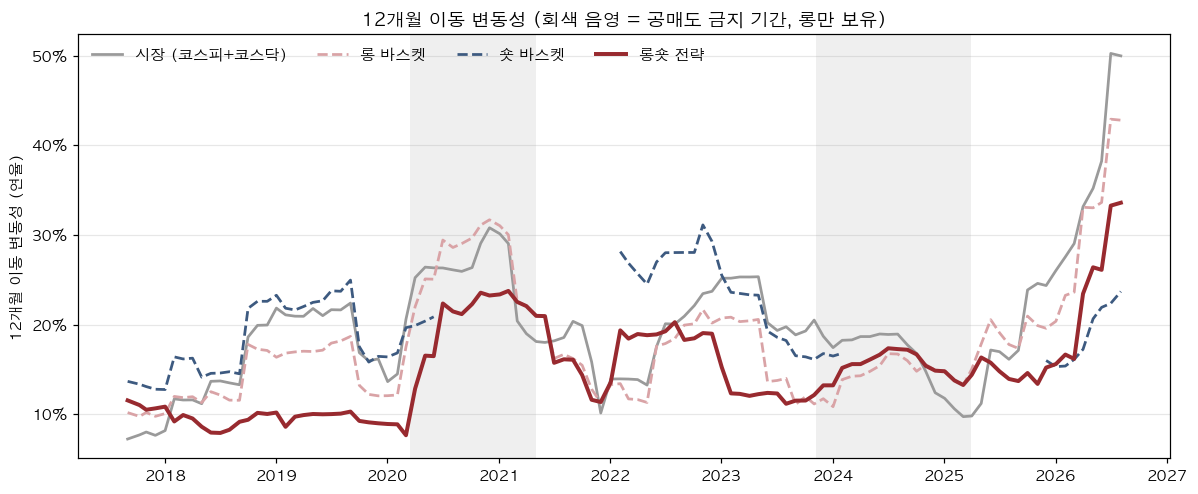

In [18]:
RV = pd.DataFrame({"롱 바스켓": long_leg, "숏 바스켓": short_bsk, "롱숏 전략": tot, "시장 (코스피+코스닥)": mk}).rolling(12, min_periods=9).std() * np.sqrt(12)
fig, ax = plt.subplots(figsize=(11, 4.6))
for a0, b0 in S.SHORT_BANS: ax.axvspan(pd.Timestamp(a0), pd.Timestamp(b0), color="#EFEFEF", lw=0)
for c, col, lw, ls in (("시장 (코스피+코스닥)", "#9A9A9A", 1.8, "-"), ("롱 바스켓", "#D9A3A6", 1.8, "--"), ("숏 바스켓", "#3D5A80", 1.8, "--"), ("롱숏 전략", "#982A2F", 2.6, "-")):
    ax.plot(entry, RV[c].values, color=col, lw=lw, ls=ls, label=c)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}")); ax.set_ylabel("12개월 이동 변동성 (연율)"); ax.grid(axis="y", alpha=.3)
ax.legend(frameon=False, ncol=4, loc="upper left"); ax.set_title("12개월 이동 변동성 (회색 음영 = 공매도 금지 기간, 롱만 보유)")
plt.tight_layout(); fig.savefig(OUT / "fig_rolling_vol.png", dpi=160); plt.show()

## 15. 설정값 민감도
확정 설정에서 **한 가지만** 바꿨을 때의 Sharpe입니다 (약 1~2분). 굵은 값이 아니라 주변 값에서도 성과가 유지되는지 봅니다.
혼합 비율은 Sharpe로 고른 값이 아니라 **1,000억·5일 체결률이 80%를 넘는 가장 작은 값**이라, 체결률과 함께 봅니다.

In [19]:
D2 = S.add_alt_signals(D); P0 = S.PARAMS
GRID = [("롱 비율", "LPCT", [0.08, 0.10, 0.12]), ("숏 비율", "SPCT", [0.08, 0.10, 0.12, 0.15]),
        ("숏 업종 종목 수 상한", "IND_MAX_N", [2, 3, 4, 99]), ("롱 신호", "LONG_SIG", ["sur", "sur18", "sur24", "raw_sig"]),
        ("롱 밴드", "BAND_L", [1.5, 2.0, 2.5]), ("숏 밴드", "BAND_S", [1.5, 2.0, 3.0]), ("숏 교체 주기(개월)", "REB", [1, 2, 3]),
        ("손절", "STOP", [None, 0.2, 0.3, 0.4]), ("변동성 반감기(일)", "HL", [10, 20, 40, 60]),
        ("숏 업종 비중 상한", "IND_W_CAP_S", [None, 0.20, 0.25, 0.30, 0.35, 0.40]), ("롱 업종 비중 상한", "IND_W_CAP_L", [None, 0.20, 0.25, 0.30, 0.35, 0.40])]
NAME_ = {"sur": "SUR 12개월", "sur18": "SUR 18개월", "sur24": "SUR 24개월", "raw_sig": "원 리비전", 99: "없음", None: "없음"}
rows = []
for lab, key, vals in GRID:
    for v in vals:
        r = S.run_backtest(S.with_halflife(D2, v), P0)[0] if key == "HL" else S.run_backtest(D2, {**P0, key: v})[0]
        n_ = (1 + r.ex + r.rf).cumprod()
        rows.append({"손잡이": lab, "값": NAME_.get(v, v), "확정": v == (20 if key == "HL" else P0[key]), "Sharpe": S.sharpe(r),
                     "CAGR": n_.iloc[-1] ** (12 / len(r)) - 1, "MDD": (n_ / n_.cummax() - 1).min()})
SENS = pd.DataFrame(rows); SENS.to_csv(OUT / "sensitivity.csv", encoding="utf-8-sig", index=False)
for lab, g in SENS.groupby("손잡이", sort=False):
    print(f"{lab:14s}", " · ".join(f"[{v} {s_:.2f}]" if c else f"{v} {s_:.2f}" for v, s_, c in zip(g["값"], g.Sharpe, g["확정"])))
r21 = S.run_backtest(D2, {**P0, "REB": 2, "REB_OFF": 1})[0]
print(f"숏 2개월 교체를 한 달 늦게 시작하면 {S.sharpe(r21):.2f} → 두 시작 달 평균 {(S.sharpe(r21) + SENS[(SENS['손잡이'] == '숏 교체 주기(개월)') & (SENS['값'] == 2)].Sharpe.iloc[0]) / 2:.2f}")

롱 비율           0.08 1.26 · [0.1 1.26] · 0.12 1.17
숏 비율           0.08 1.21 · [0.1 1.26] · 0.12 1.28 · 0.15 1.24
숏 업종 종목 수 상한   2 1.36 · [3 1.26] · 4 1.17 · 없음 1.16
롱 신호           [SUR 12개월 1.26] · SUR 18개월 1.17 · SUR 24개월 1.10 · 원 리비전 1.06
롱 밴드           1.5 1.17 · [2.0 1.26] · 2.5 1.21
숏 밴드           1.5 1.23 · [2.0 1.26] · 3.0 1.26
숏 교체 주기(개월)    [1 1.26] · 2 1.38 · 3 1.27
손절             없음 1.25 · 0.2 1.25 · [0.3 1.26] · 0.4 1.23
변동성 반감기(일)     10 1.24 · [20 1.26] · 40 1.25 · 60 1.24
숏 업종 비중 상한     없음 1.26 · 0.2 1.26 · 0.25 1.26 · [0.3 1.26] · 0.35 1.26 · 0.4 1.26
롱 업종 비중 상한     없음 1.25 · 0.2 1.27 · 0.25 1.27 · [0.3 1.26] · 0.35 1.25 · 0.4 1.25


숏 2개월 교체를 한 달 늦게 시작하면 1.13 → 두 시작 달 평균 1.25


In [20]:
rows = []
for aL, aS in [(a, 0.70) for a in (0.0, 0.45, 0.55, 0.65, 0.75, 0.85)] + [(0.65, a) for a in (0.0, 0.5, 0.6, 0.8, 0.9)]:
    r, h, _, _ = S.run_backtest(D, {**S.PARAMS, "BLEND_L": aL, "BLEND_S": aS}); f = S.fill_rate(D, r, h, 1000e8, 5)
    rows.append({"롱 a": aL, "숏 a": aS, "Sharpe": S.sharpe(r), "연변동성": (r.ex + r.rf).std() * np.sqrt(12), "1,000억·5일 체결률 롱": f["롱"], "1,000억·5일 체결률 숏": f["숏"]})
BL = pd.DataFrame(rows); BL.to_csv(OUT / "blend_sensitivity.csv", encoding="utf-8-sig", index=False)
fmt(BL, pct=["연변동성", "1,000억·5일 체결률 롱", "1,000억·5일 체결률 숏"], dec=["Sharpe", "롱 a", "숏 a"])

,롱 a,숏 a,Sharpe,연변동성,"1,000억·5일 체결률 롱","1,000억·5일 체결률 숏"
0,0.00,0.70,1.31,14.3%,49.4%,80.2%
1,0.45,0.70,1.34,16.5%,70.9%,80.2%
2,0.55,0.70,1.30,17.6%,76.0%,80.2%
3,0.65,0.70,1.26,18.7%,81.2%,80.2%
4,0.75,0.70,1.21,19.9%,86.3%,80.2%
5,0.85,0.70,1.17,21.3%,91.2%,80.2%
6,0.65,0.00,1.21,20.4%,81.2%,54.7%
7,0.65,0.50,1.26,18.8%,81.2%,71.4%
8,0.65,0.60,1.26,18.7%,81.2%,75.7%
9,0.65,0.80,1.24,18.7%,81.2%,84.9%


## 16. 앵커 검증 — 앞 기간만 보고 골랐다면
연구 단계에서 시험한 **다른 설정 63개**(공분산·신호·비중을 바꾼 것, 롱 100%·숏 100% 규칙을 지키는 것만)와 v6·v7·v8, 모두 66개를 한 줄에 세워,
앞 구간 Sharpe로 고른 설정이 뒤 구간에서 어땠는지 봅니다.
- ① S1(2016-12~2020-01)으로 고르고 S2(2020-02~2023-04)에서 확인
- ② S1+S2로 고르고 S3(2023-05~2026-07)에서 확인

다른 설정의 월별 수익률은 `code/research_results/anchored_configs_monthly_ret.csv`에서 읽습니다. 고가·저가 기반 공분산 등 이 엔진에 없는 방식이 섞여 있어
다시 만들지 않고 연구 단계 결과를 그대로 씁니다(열 이름의 `|0`, `|1`은 숏 2개월 교체의 시작 달 두 가지, 표는 둘의 평균. 포지션 회계 수정 전 값이라 Sharpe 0.002 안팎의 차이가 있을 수 있음).
v6(= v7에서 롱 업종 상한만 뺀 것)·v7·v8은 이 엔진으로 계산합니다. 비교를 맞추려고 다른 설정에도 같은 숏 매도대금 이자를 더합니다.

,설정 수,학습 1위 설정,학습 1위: 학습 → 표본 밖 (순위),v8: 학습 순위 → 표본 밖 (순위),v7 표본 밖 (순위),v5 표본 밖,중앙
단계,,,,,,,
① S1로 선택 → S2,66,v5 + 숏 매월 교체,1.79 → 1.40 (31위),43위 → 1.42 (27위),1.57 (4위),1.36,1.38
② S1+S2로 선택 → S3,66,v6 (숏 업종 30%),1.56 → 1.12 (49위),44위 → 1.37 (32위),1.31 (36위),1.08,1.34


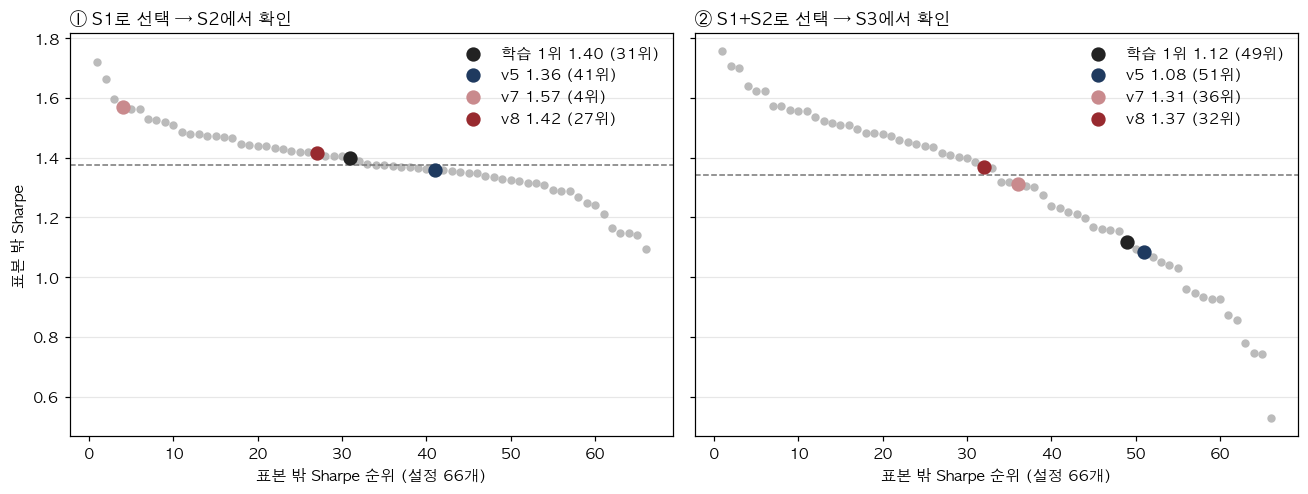

In [21]:
REF = pd.read_csv(CODE / "research_results" / "anchored_configs_monthly_ret.csv", index_col=0, parse_dates=True)
X = REF.add(M.rebate.reindex(REF.index).fillna(0.0), axis=0)
M6 = S.run_backtest(D, {**S.PARAMS, "BLEND_L": 0.0, "BLEND_S": 0.0, "IND_W_CAP_L": None})[0]      # v6: 최소분산만, 롱 업종 상한 없음
for o in (0, 1): X[f"v8 (체결률 고려)|{o}"] = tot; X[f"v7 (체결률 미고려)|{o}"] = tot7; X[f"v6 (숏 업종 30%)|{o}"] = M6.ex + M6.rf
e_ = X.sub(M.rf, axis=0); sh_ = lambda x: x.mean() * 12 / (x.std() * np.sqrt(12))
SEG2 = {"S1": ("2016-12-01", "2020-01-31"), "S12": ("2016-12-01", "2023-04-30"), "S2": ("2020-02-01", "2023-04-30"), "S3": ("2023-05-01", "2026-07-31")}
names_ = sorted(set(c.split("|")[0] for c in X.columns))
AW = pd.DataFrame({l: {k: np.mean([sh_(e_[c].loc[a:b]) for c in X.columns if c.split("|")[0] == l]) for k, (a, b) in SEG2.items()} for l in names_}).T
AW = AW[~AW.index.str.contains("다리")]                  # 롱·숏 100% 규칙을 지키지 않는 설정 제외
AW.to_csv(OUT / "anchored_validation.csv", encoding="utf-8-sig")
V8, V7 = "v8 (체결률 고려)", "v7 (체결률 미고려)"; rows = []
for tr, te, lab in (("S1", "S2", "① S1로 선택 → S2"), ("S12", "S3", "② S1+S2로 선택 → S3")):
    rk_tr, rk_te = AW[tr].rank(ascending=False), AW[te].rank(ascending=False); ch = AW[tr].idxmax()
    rows.append({"단계": lab, "설정 수": len(AW), "학습 1위 설정": ch, "학습 1위: 학습 → 표본 밖 (순위)": f"{AW.loc[ch, tr]:.2f} → {AW.loc[ch, te]:.2f} ({int(rk_te[ch])}위)",
                 "v8: 학습 순위 → 표본 밖 (순위)": f"{int(rk_tr[V8])}위 → {AW.loc[V8, te]:.2f} ({int(rk_te[V8])}위)",
                 "v7 표본 밖 (순위)": f"{AW.loc[V7, te]:.2f} ({int(rk_te[V7])}위)", "v5 표본 밖": f"{AW.loc['v5', te]:.2f}", "중앙": f"{AW[te].median():.2f}"})
display(pd.DataFrame(rows).set_index("단계"))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, (tr, te, ttl) in zip(axs, (("S1", "S2", "① S1로 선택 → S2에서 확인"), ("S12", "S3", "② S1+S2로 선택 → S3에서 확인"))):
    o = AW[te].sort_values(ascending=False); idx = list(o.index)
    ax.scatter(range(1, len(o) + 1), o.values, s=20, color="#BBBBBB"); ax.axhline(o.median(), color="#777777", lw=1, ls="--")
    for nm, col, lab in ((AW[tr].idxmax(), "#222222", "학습 1위"), ("v5", "#1F3A5F", "v5"), (V7, "#C98A8D", "v7"), (V8, "#982A2F", "v8")):
        k = idx.index(nm); ax.scatter([k + 1], [o.iloc[k]], s=70, color=col, zorder=4, label=f"{lab} {o.iloc[k]:.2f} ({k + 1}위)")
    ax.set_title(ttl, loc="left", fontsize=11); ax.set_xlabel(f"표본 밖 Sharpe 순위 (설정 {len(o)}개)"); ax.legend(frameon=False, fontsize=10); ax.grid(axis="y", alpha=.3)
axs[0].set_ylabel("표본 밖 Sharpe"); plt.tight_layout(); fig.savefig(OUT / "fig_anchored_validation.png", dpi=160); plt.show()

## 17. 저장된 결과

In [22]:
sorted(p.name for p in OUT.iterdir())

['anchored_validation.csv',
 'blend_sensitivity.csv',
 'costs.csv',
 'factor_regression.csv',
 'fig_anchored_validation.png',
 'fig_heatmaps_3x3.png',
 'fig_heatmaps_4x4.png',
 'fig_heatmaps_5x5.png',
 'fig_nav_drawdown.png',
 'fig_quintiles.png',
 'fig_rolling_vol.png',
 'fill_rate.csv',
 'heatmap_dtc_x_size_3x3.csv',
 'heatmap_dtc_x_size_4x4.csv',
 'heatmap_dtc_x_size_5x5.csv',
 'heatmap_sur_x_size_3x3.csv',
 'heatmap_sur_x_size_4x4.csv',
 'heatmap_sur_x_size_5x5.csv',
 'holdings_long_last.csv',
 'holdings_short_last.csv',
 'long_only_compare.csv',
 'monthly.csv',
 'nav.csv',
 'performance.csv',
 'quintiles.csv',
 'sensitivity.csv',
 'stop_events.csv',
 'v8_vs_v7.csv',
 'vol_eval.csv',
 'yearly.csv']